# Fastai Practical Deep Learning for Coders

This notebook contains my course notes https://course.fast.ai/.

## Lesson "0"

https://www.youtube.com/watch?v=gGxe2mN3kAg.

56:08 - How to get started with AWS EC2. See 

* https://course19.fast.ai/start_aws.html.
* https://dr563105.github.io/blog/aws-setup/.
* https://blog.jasonweddington.com/2021/04/getting-started-with-fastai-on-aws-ec2/.
* https://docs.aws.amazon.com/dlami/latest/devguide/setup-jupyter.html.



## Lesson 1: Getting started

https://course.fast.ai/Lessons/lesson1.html.

See also:

* Official topics: https://forums.fast.ai/t/lesson-1-official-topic/95287.
* Blog: [fastai: A larered API for Deep Learning](https://www.fast.ai/2020/02/13/fastai-A-Layered-API-for-Deep-Learning/).
* Article: [fastai: A Layered API for Deep Learning](https://arxiv.org/abs/2002.04688).
* Notebooks of the couse: https://course.fast.ai.
* Notebooks of the book: https://github.com/fastai/fastbook/.
* fastai documentation: 
    * https://docs.fast.ai
    * https://timm.fast.ai
    * https://rwightman.github.io
* [Jeremy Howard's Kaggle](https://kaggle.com/jhoward/notebooks).
    * https://www.kaggle.com/jhoward/code.
    * https://kagglr.com/code/jhoward/saving-a-basic-fastai-model/.
    * [Jupyter notebook 101](https://www.kaggle.com/code/jhoward/jupyter-notebook-101).
    * [Is it a bird? Creating a model from your own data?](https://www.kaggle.com/code/jhoward/is-it-a-bird-creating-a-model-from-your-own-data)





## Lesson 2: Deployment

https://course.fast.ai/Lessons/lesson2.html

See also:

* Official topic: https://forums.fast.ai/t/lesson-2-official-topic/96033.
* https://github.com/fastai/course22/blob/master/02-saving-a-basic-fastai-model.ipynb
* https://jupyter-contrib-nbextensions.readthedocs.io to install "Table of Contents (2)".

To search images: 

```python
ims = search_images_ddg('grissly bear')
len(ims)
```

To edit files on git repository with Visual Studio Code: `code .`.

55:32<br>
We talk about https://github.com/fastai/fastsetup.
He recommend [mamba](https://github.com/mamba-org/mamba) to install fastai: `mamba install fastai` 

1:02:47<br>
He explain how to use the Hugging APIs in our own javascript applications.



## Lesson 3: Neural net foundations

https://course.fast.ai/Lessons/lesson3.html

See also: 

* Official topic: https://forums.fast.ai/t/lesson-3-official-topic/96254
* Fastbook on GitHub: https://github.com/fastai/fastbook
* Fastbook on Colab: https://colab.research.google.com/github/fastai/fastbook
* Notebook: https://github.com/fastai/course22/blob/master/slides/birds.ipynb


In [1]:
import numpy as np
import matplotlib.pyplot as plt

See https://matplotlib.org/stable/gallery/lines_bars_and_markers/errorbar_limits_simple.html#sphx-glr-gallery-lines-bars-and-markers-errorbar-limits-simple-py

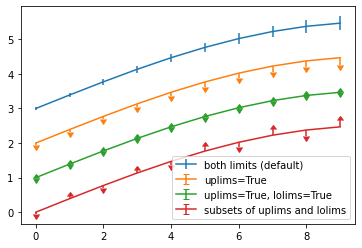

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
x = np.arange(10)
y = 2.5 * np.sin(x / 20 * np.pi)
yerr = np.linspace(0.05, 0.2, 10)

plt.errorbar(x, y + 3, yerr=yerr, label='both limits (default)')

plt.errorbar(x, y + 2, yerr=yerr, uplims=True, label='uplims=True')

plt.errorbar(x, y + 1, yerr=yerr, uplims=True, lolims=True,
             label='uplims=True, lolims=True')

upperlimits = [True, False] * 5
lowerlimits = [False, True] * 5
plt.errorbar(x, y, yerr=yerr, uplims=upperlimits, lolims=lowerlimits,
             label='subsets of uplims and lolims')

plt.legend(loc='lower right')

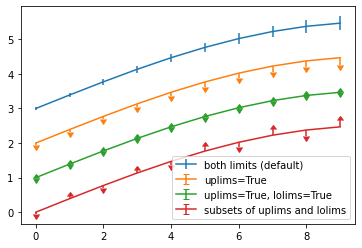

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
x = np.arange(10)
y = 2.5 * np.sin(x / 20 * np.pi)
yerr = np.linspace(0.05, 0.2, 10)

plt.errorbar(x, y + 3, yerr=yerr, label='both limits (default)')

plt.errorbar(x, y + 2, yerr=yerr, uplims=True, label='uplims=True')

plt.errorbar(x, y + 1, yerr=yerr, uplims=True, lolims=True,
             label='uplims=True, lolims=True')

upperlimits = [True, False] * 5
lowerlimits = [False, True] * 5
plt.errorbar(x, y, yerr=yerr, uplims=upperlimits, lolims=lowerlimits,
             label='subsets of uplims and lolims')

plt.legend(loc='lower right')## How do we fit a function to data?

## How do we fit a function to data?

In [4]:
import torch

In [5]:
plt.rc('figure', dpi=90)
    
def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

See https://github.com/fastai/course22/blob/master/slides/birds.ipynb

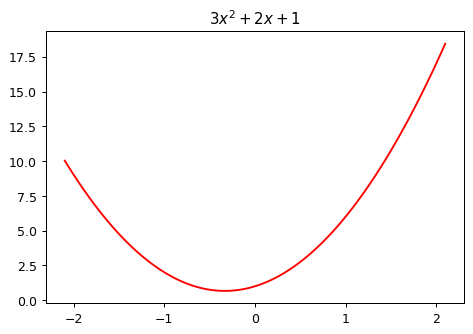

In [6]:
def f(x): return 3*x**2 + 2*x + 1

plot_function(f, "$3x^2 + 2x + 1$")

In [7]:
def quad(a, b, c, x): return a*x**2 + b*x + c

In [8]:
quad(3,2,1,1.5)

10.75

In [9]:
from functools import partial
def mk_quad(a,b,c): return partial(quad,a,b,c)

In [10]:
f = mk_quad(3,2,1)
f(1.5)

10.75

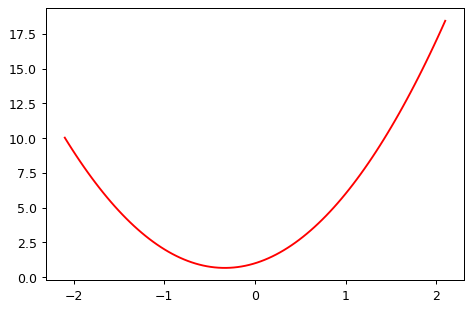

In [11]:
plot_function(f)

In [12]:
from numpy.random import normal,seed,uniform
np.random.seed(42)
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

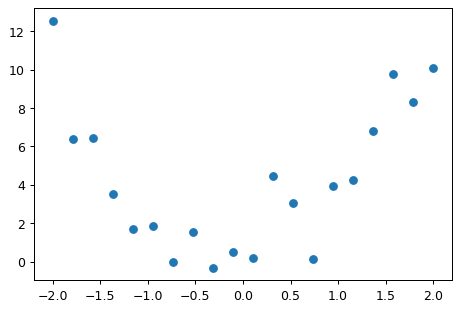

In [13]:
x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.3, 1.5)
plt.scatter(x,y);

In [15]:
from ipywidgets import interact
@interact(a=1.5, b=1.5, c=1.5)
def plot_quad(a, b, c):
    plt.scatter(x,y)
    plot_function(mk_quad(a,b,c), ylim=(-3,12))

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [16]:
def mse(preds, acts): return ((preds-acts)**2).mean()

In [17]:
@interact(a=1.5, b=1.5, c=1.5)
def plot_quad(a, b, c):
    f = mk_quad(a,b,c)
    plt.scatter(x,y)
    loss = mse(f(x), y)
    plot_function(f, ylim=(-3,12), title=f"MSE: {loss:.4f}")

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [18]:
def quad_mse(params):
    f = mk_quad(*params)
    return mse(f(x), y)

In [19]:
quad_mse([1.5, 1.5, 1.5])

tensor(5.8336, dtype=torch.float64)

In [20]:
# Rank 1 tensor.
abc = torch.tensor([1.5,1.5,1.5])
abc.requires_grad_()

tensor([1.5000, 1.5000, 1.5000], requires_grad=True)

In [21]:
loss = quad_mse(abc)
loss

tensor(5.8336, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [22]:
loss.backward()

In [23]:
abc.grad

tensor([-5.1419,  2.8472, -1.1009])

In [24]:
with torch.no_grad():
    abc -= abc.grad*0.01
    loss = quad_mse(abc)
    
print(f'loss={loss:.4f}')

loss=5.4893


In [25]:
for i in range(5):
    loss = quad_mse(abc)
    loss.backward()
    with torch.no_grad(): abc -= abc.grad*0.01
    print(f'step={i}; loss={loss:.2f}')

step=0; loss=5.49
step=1; loss=4.90
step=2; loss=4.23
step=3; loss=3.67
step=4; loss=3.33


See https://pytorch.org/docs/stable/generated/torch.clamp.html#torch.clamp

In [26]:
def rectified_linear(m,b,x):
    y = m*x+b
    return torch.clamp(y, 0.)

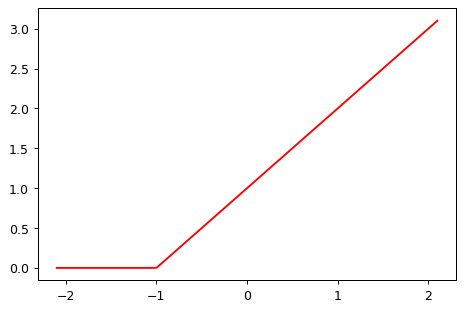

In [27]:
plot_function(partial(rectified_linear, 1,1))

In [28]:
@interact(m=1.5, b=1.5)
def plot_relu(m, b):
    plot_function(partial(rectified_linear, m,b), ylim=(-1,4))

interactive(children=(FloatSlider(value=1.5, description='m', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [29]:
def double_relu(m1,b1,m2,b2,x):
    return rectified_linear(m1,b1,x) + rectified_linear(m2,b2,x)

In [30]:
@interact(m1=-1.5, b1=-1.5, m2=1.5, b2=1.5)
def plot_double_relu(m1, b1, m2, b2):
    plot_function(partial(double_relu, m1,b1,m2,b2), ylim=(-1,6))

interactive(children=(FloatSlider(value=-1.5, description='m1', max=1.5, min=-4.5), FloatSlider(value=-1.5, de…

In [31]:
import sys

class Pet:
    if sys.argv[1] == "cat":
        def say(self):
            print("Meow! \N{CAT}")
    else:
        def say(self):
            print("Woof! \N{DOG}")
            
Pet().say() 

Woof! 🐕


## Lesson 4: Natural Language NLP

https://course.fast.ai/Lessons/lesson4.html

See also:

* [Getting started with NLP for absolute beginners](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners) on Kaggle
* [Python for Data Analysis, 3E](https://wesmckinney.com/book/)
